In [1]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_root = r"E:/Studies/Self/CCTV-Threat-Detection/Data/Smart-City-CCTV-Violence-Detection-Dataset (SCVD)\SCVD_converted"

train_dir = os.path.join(dataset_root, "Train")
test_dir = os.path.join(dataset_root, "Test")

classes = ["Normal", "Violence", "Weaponized"]
print("Classes:", classes)
print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))

Classes: ['Normal', 'Violence', 'Weaponized']
Train classes: ['Normal', 'Violence', 'Weaponized']
Test classes: ['Normal', 'Violence', 'Weaponized']


In [3]:
class VideoDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None, frames_per_clip=16):
        self.samples = []
        self.transform = transform
        self.frames_per_clip = frames_per_clip
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            class_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(class_dir):
                if fname.endswith(".avi"):
                    self.samples.append((os.path.join(class_dir, fname), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        cap = cv2.VideoCapture(video_path)
        frames = []
        while len(frames) < self.frames_per_clip and cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)
        cap.release()

        # Pad if fewer frames
        while len(frames) < self.frames_per_clip:
            frames.append(torch.zeros_like(frames[0]))

        video_tensor = torch.stack(frames)  # shape: (T, C, H, W)
        return video_tensor, label

In [4]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = VideoDataset(train_dir, classes, transform)
test_dataset = VideoDataset(test_dir, classes, transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 399
Test samples: 82


In [5]:
#Model (ResNet + LSTM hybrid)
class ViolenceClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super(ViolenceClassifier, self).__init__()
        self.resnet = models.resnet18(pretrained=True)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 128)
        self.lstm = nn.LSTM(128, 64, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        # x shape: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        features = self.resnet(x)
        features = features.view(B, T, -1)
        lstm_out, _ = self.lstm(features)
        out = self.fc(lstm_out[:, -1, :])
        return out

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViolenceClassifier(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for videos, labels in train_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/10, Loss: 0.9507
Epoch 2/10, Loss: 0.6689
Epoch 3/10, Loss: 0.4742
Epoch 4/10, Loss: 0.3883
Epoch 5/10, Loss: 0.3643
Epoch 6/10, Loss: 0.2371
Epoch 7/10, Loss: 0.1762
Epoch 8/10, Loss: 0.2131
Epoch 9/10, Loss: 0.1847
Epoch 10/10, Loss: 0.1542


              precision    recall  f1-score   support

      Normal       0.86      0.80      0.83        46
    Violence       0.18      0.25      0.21        12
  Weaponized       0.64      0.58      0.61        24

    accuracy                           0.66        82
   macro avg       0.56      0.55      0.55        82
weighted avg       0.69      0.66      0.67        82



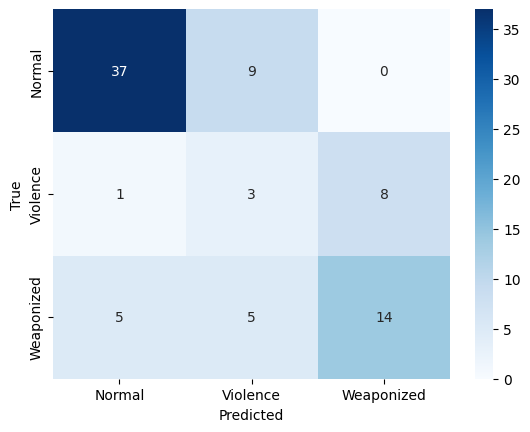

In [11]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for videos, labels in test_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()